# SQL Agent

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

## 실습 환경 준비

In [3]:
import pathlib
import requests

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"
local_path = pathlib.Path("Chinook.db")

if local_path.exists():
    print(f"{local_path} 파일이 이미 존재합니다. 다운로드를 건너뜁니다.")
else:
    response = requests.get(url, timeout=30)

    if response.status_code == 200:
        local_path.write_bytes(response.content)
        print(f"{local_path} 파일 다운로드 완료")
    else:
        print(f"다운로드 실패. status code: {response.status_code}")

Chinook.db 파일이 이미 존재합니다. 다운로드를 건너뜁니다.


In [4]:

from langchain_community.utilities import SQLDatabase

# sqlite:/// 는 로컬 SQLite 파일에 연결할 때 사용하는 URI 형식이다.
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

print(f"SQL dialect: {db.dialect}")
print(f"사용 가능한 테이블 목록: {db.get_usable_table_names()}")

SQL dialect: sqlite
사용 가능한 테이블 목록: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


## SQL Agent가 사용할 도구 만들기

In [5]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain.chat_models import init_chat_model

model = init_chat_model('openai:gpt-4.1-mini',temperature = 0)

toolkit = SQLDatabaseToolkit(db=db,llm=model)
tools = toolkit.get_tools()

for tool in tools:
    print(f'[{tool.name}]')
    print(tool.description)
    print()

[sql_db_query]
Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.

[sql_db_schema]
Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3

[sql_db_list_tables]
Input is an empty string, output is a comma-separated list of tables in the database.

[sql_db_query_checker]
Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!



In [6]:
# 이후 노드 구성에서 특정 도구만 꺼내쓰기 위해 선언해 둔다.
list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
query_checker_tool = next(tool for tool in tools if tool.name == "sql_db_query_checker")

## LangGraph로 작업 단계 나누기
1. 테이블 목록을 조회한다.
2. 질문 해결에 필요한 테이블의 스키마를 조회한다.
3. 사용자의 질문에 맞는 SQL을 생성한다.
4. 생성된 SQL을 실행 전에 다시 검토한다.
5. 검토된 SQL을 실행한다.
6. 실행 결과를 바탕으로 최종 답변을 생성한다.

In [7]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage,HumanMessage,ToolMessage

### 1. 테이블 목록 조회 노드
첫 번째 노드는 항상 테이블 목록을 조회한다.

In [8]:
def list_tables(state:MessagesState):
    """데이터 베이스의 테이블 목록을 조회하는 노드이다."""

    tool_call = {
        "name":"sql_db_list_tables",
        "args":{},
        "id":"list_tables_call",
        "type":"tool_call"
    }

    # AI가 이 도구를 호출하려고 했다는 기록을 남기기 위해서
    tool_call_messages = AIMessage(content='',tool_calls=[tool_call])

    # 실제 테이블 목록 조회 도구 실행
    tool_message = list_tables_tool.invoke(tool_call)

    # 이후 LLM이 읽기 쉽도록 테이블 목록을 일반 AIMessage로도 추가
    response = AIMessage(content=f'사용 가능한 테이블 목록 : {tool_message.content}')

    return {'messages':[tool_call_messages,tool_message,response]}

In [9]:
# 노드 단위 테스트

state = {'messages': [HumanMessage(content='평균 재생 시간이 가장 긴 장르는 무엇인가?')]}
response = list_tables(state)

for message in response['messages']:
    message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (list_tables_call)
 Call ID: list_tables_call
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

사용 가능한 테이블 목록 : Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track


### 2. 스키마 조회 노드
질문 해결에 필요한 테이블의 스키마를 조회한다.

In [10]:
def call_get_schema(state:MessagesState):
    """사용자 질문과 테이블 목록을 보고 필요한 테이블 스키마 조회 도구를 호출한다."""

    # tool_choice = 'any'의 의미는 제공된 tool 중 하나를 호출하는 것을 강제하는 의미
    llm_with_tools = model.bind_tools([get_schema_tool],tool_choice='any')
    response = llm_with_tools.invoke(state['messages'])

    return {'messages' : [response]}

In [11]:
# 노드 단위 테스트
# 위의 테스트에서 응답 받은 response에 담긴 messages 재사용

state_after_list_tables = {
    "messages" : [
        HumanMessage(content="평균 재생시간이 가장 긴 장르는 무엇인가?"),
        *response['messages']
    ]
}

schema_call_response = call_get_schema(state_after_list_tables)
schema_call_response['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_Am1r93fMeASP7UydLXrSifDS)
 Call ID: call_Am1r93fMeASP7UydLXrSifDS
  Args:
    table_names: Genre, Track


### 3. SQL 생성 노드

In [12]:
generate_query_system_prompt = f"""
당신은 SQL 데이터베이스와 상호작용하는 Agent입니다.

사용자의 질문을 보고 실행할 수 있는 올바른 {db.dialect} SQL 쿼리를 작성하세요.
사용자가 특정 개수를 명시하지 않으면 결과는 최대 5개로 제한하세요.
가장 의미 있는 결과가 먼저 나오도록 관련 컬럼 기준으로 정렬하세요.

주의사항:
- 특정 테이블의 모든 컬럼을 조회하지 마세요.
- 질문 해결에 필요한 컬럼만 조회하세요.
- INSERT, UPDATE, DELETE, DROP, ALTER, CREATE 같은 데이터 변경 또는 구조 변경 문장은 절대 만들지 마세요.
- SQL 실행이 필요하면 반드시 sql_db_query 도구를 호출하세요.
- 도구 실행 결과가 주어졌다면 그 결과를 바탕으로 한국어로 답변하세요.
"""

def generate_query(state: MessagesState):
    """질문 해결에 필요한 SQL을 생성하거나, 실행 결과를 바탕으로 최종 답변을 생성한다."""

    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }

    # 도구 호출을 강제하지 않는다.
    # SQL 실행이 필요하면 run_query_tool을 호출한다.
    # 이미 SQL 실행 결과가 있다면 모델이 최종 답변을 생성한다.
    llm_with_tools = model.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}

### 4. SQL 검토 노드

In [13]:
check_query_system_prompt = f"""
당신은 SQL 검토 전문가입니다.

다음 {db.dialect} SQL 쿼리를 실행하기 전에 꼼꼼히 검토하세요.

검토 기준:
- NOT IN과 NULL 값 조합으로 인한 문제
- UNION과 UNION ALL 사용 오류
- BETWEEN의 경계 포함 여부
- 조건절의 데이터 타입 불일치
- 식별자 quoting 문제
- 함수 인자 개수 오류
- CAST가 필요한 부분
- JOIN에 사용한 컬럼이 올바른지 여부
- 존재하지 않는 테이블이나 컬럼 사용 여부
- 데이터 변경 또는 구조 변경 문장 포함 여부

문제가 있으면 SQL을 수정하세요.
문제가 없으면 원래 SQL을 그대로 사용하세요.

검토가 끝나면 반드시 sql_db_query 도구를 호출하세요.
"""

def check_query(state: MessagesState):
    """생성된 SQL을 실행하기 전에 검토하고, 실행할 SQL 도구 호출을 다시 만든다."""

    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    tool_call = state["messages"][-1].tool_calls[0]
    query = tool_call["args"]["query"]

    user_message = {"role": "user", "content": query}

    llm_with_tools = model.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])

    response.id = state["messages"][-1].id

    return {"messages": [response]}

### 5. 조건 분기 함수

In [14]:
from typing import Literal
from langgraph.graph import END, START, StateGraph

def should_continue(state:MessagesState) -> Literal[END,'check_query']:
    """마지막 메세지에 도구 호출이 있으면 SQL 검토 단계로 이동한다."""

    messages = state['messages']
    last_message = messages[-1]

    if not last_message.tool_calls:
        return END
    
    return 'check_query'

### SQL Agent 그래프 구성

In [15]:
from langgraph.prebuilt import ToolNode

get_schema_node = ToolNode([get_schema_tool],name='get_schema')
run_query_node = ToolNode([run_query_tool],name="run_query")

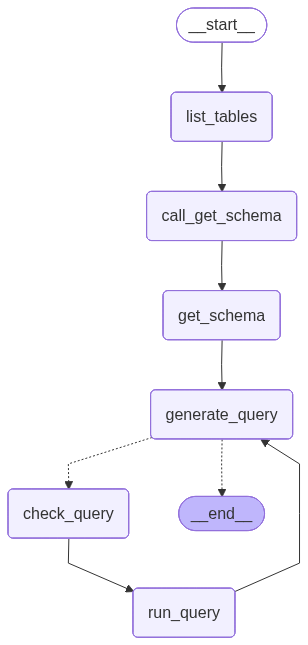

In [16]:
builder = StateGraph(MessagesState)

# 노드 등록
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node,"get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node,"run_query")

# 기본 흐름
builder.add_edge(START, "list_tables")
builder.add_edge("list_tables","call_get_schema")
builder.add_edge("call_get_schema","get_schema")
builder.add_edge("get_schema","generate_query")

# generate_query 이후에는 도구 호출 여부에 따라 분기한다.
builder.add_conditional_edges("generate_query", should_continue)

builder.add_edge("check_query","run_query")
builder.add_edge("run_query","generate_query")

agent = builder.compile()
agent

### SQL Agent 실행

In [17]:
def print_stream_update(question: str):
    """그래프 실행 과정을 노드 단위로 출력하는 함수"""

    for chunk in agent.stream(
        {'messages':[('human',question)]},
        stream_mode='updates'
    ):
        for node_name, update in chunk.items():
            print("="*100)
            print("Update from mode: ",node_name)

            if 'messages' in update:
                update['messages'][-1].pretty_print()
            else:
                print(update)

            print()

In [18]:
print_stream_update("평균 재생 시간이 가장 긴 장르는 무엇인가?")

Update from mode:  list_tables
================================== Ai Message ==================================

사용 가능한 테이블 목록 : Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

Update from mode:  call_get_schema
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_pKvtfMNPg2K9IAmWEboIodLE)
 Call ID: call_pKvtfMNPg2K9IAmWEboIodLE
  Args:
    table_names: Genre, Track

Update from mode:  get_schema
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Genre" (
	"GenreId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("GenreId")
)

/*
3 rows from Genre table:
GenreId	Name
1	Rock
2	Jazz
3	Metal
*/


CREATE TABLE "Track" (
	"TrackId" INTEGER NOT NULL, 
	"Name" NVARCHAR(200) NOT NULL, 
	"AlbumId" INTEGER, 
	"MediaTypeId" INTEGER NOT NULL, 
	"GenreId" INTEGER, 
	"Composer" NVARCHAR(220), 
	"Millisecond

In [19]:
print_stream_update('구매 금액이 가장 큰 고객 5명을 알려줘.')

Update from mode:  list_tables
================================== Ai Message ==================================

사용 가능한 테이블 목록 : Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

Update from mode:  call_get_schema
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_iYZbIF0kQhKX0b6w8i1uTaGe)
 Call ID: call_iYZbIF0kQhKX0b6w8i1uTaGe
  Args:
    table_names: Customer, Invoice

Update from mode:  get_schema
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Customer" (
	"CustomerId" INTEGER NOT NULL, 
	"FirstName" NVARCHAR(40) NOT NULL, 
	"LastName" NVARCHAR(20) NOT NULL, 
	"Company" NVARCHAR(80), 
	"Address" NVARCHAR(70), 
	"City" NVARCHAR(40), 
	"State" NVARCHAR(40), 
	"Country" NVARCHAR(40), 
	"PostalCode" NVARCHAR(10), 
	"Phone" NVARCHAR(24), 
	"Fax" NVARCHAR(24), 
	"Email" NVARCHAR(60) NOT NULL, 
	"Supp

In [20]:
print_stream_update('AC/DC의 앨범 목록을 알려줘.')

Update from mode:  list_tables
================================== Ai Message ==================================

사용 가능한 테이블 목록 : Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

Update from mode:  call_get_schema
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_KB22WZeYwURHF9L78dHPvPhn)
 Call ID: call_KB22WZeYwURHF9L78dHPvPhn
  Args:
    table_names: Album, Artist

Update from mode:  get_schema
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Album" (
	"AlbumId" INTEGER NOT NULL, 
	"Title" NVARCHAR(160) NOT NULL, 
	"ArtistId" INTEGER NOT NULL, 
	PRIMARY KEY ("AlbumId"), 
	FOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")
)

/*
3 rows from Album table:
AlbumId	Title	ArtistId
1	For Those About To Rock We Salute You	1
2	Balls to the Wall	2
3	Restless and Wild	2
*/


CREATE TABLE "Artist" (
	"A

## SQL Agent에서 주의해야할 질문

운영 환경에서는 다음 항목을 고려해야 한다.
- 읽기 전용 DB 계정 사용
- 접근 가능 테이블 제한
- 실행 가능 SQL 종류 제한
- 쿼리 실행 전 검토 단계 추가
- 너무 큰 결과를 반환하지 않도록 LIMIT 강제
- 로그 추적 도구로 실행 과정 확인

In [21]:
print_stream_update('Artist 테이블에서 AC/DC를 삭제해줘.')

Update from mode:  list_tables
================================== Ai Message ==================================

사용 가능한 테이블 목록 : Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

Update from mode:  call_get_schema
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_EoGBmNo66x010V0rFnXkAYTN)
 Call ID: call_EoGBmNo66x010V0rFnXkAYTN
  Args:
    table_names: Artist

Update from mode:  get_schema
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Artist" (
	"ArtistId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("ArtistId")
)

/*
3 rows from Artist table:
ArtistId	Name
1	AC/DC
2	Accept
3	Aerosmith
*/

Update from mode:  generate_query
================================== Ai Message ==================================

데이터 변경(삭제)은 할 수 없습니다. 다른 조회나 필요한 작업이 있으면 알려주세요.



## Human-in-the-loop: SQL 실행 전 사람이 검토하기

In [22]:
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langgraph.types import interrupt


@tool(
    run_query_tool.name,
    description=run_query_tool.description,
    args_schema=run_query_tool.args_schema,
)
def run_query_tool_with_interrupt(config: RunnableConfig, **tool_input):
    """SQL 실행 전에 사람의 검토를 받는 도구이다."""

    request = {
        "action": run_query_tool.name,
        "args": tool_input,
        "description": "SQL 실행 전에 쿼리를 검토하세요.",
    }

    # interrupt는 그래프 실행을 일시 중단하고 외부 입력을 기다린다.
    response = interrupt([request])

    # 1. 승인: 원래 SQL을 그대로 실행한다.
    if response["type"] == "accept":
        tool_response = run_query_tool.invoke(tool_input, config)

    # 2. 수정: 사람이 수정한 SQL로 실행한다.
    elif response["type"] == "edit":
        tool_input = response["args"]["args"]
        tool_response = run_query_tool.invoke(tool_input, config)

    # 3. 피드백: SQL을 실행하지 않고 피드백을 ToolMessage처럼 반환한다.
    elif response["type"] == "response":
        tool_response = response["args"]

    else:
        raise ValueError(f"지원하지 않는 interrupt 응답 타입입니다: {response['type']}")

    return tool_response

### Human-in-the-loop 그래프 재구성

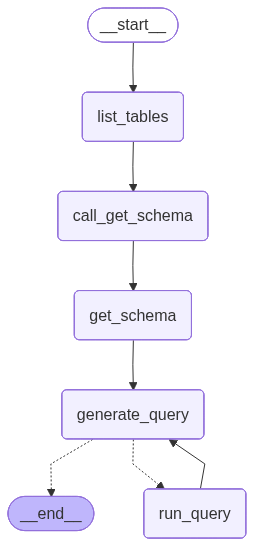

In [23]:
from langgraph.checkpoint.memory import InMemorySaver

def should_continue_with_review(state: MessagesState) -> Literal[END, "run_query"]:
    """도구 호출이 있으면 사람 검토가 포함된 run_query 노드로 이동한다."""

    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return END

    return "run_query"


# 사람이 검토하는 버전의 run_query 노드
run_query_review_node = ToolNode([run_query_tool_with_interrupt], name="run_query")

review_builder = StateGraph(MessagesState)

review_builder.add_node(list_tables)
review_builder.add_node(call_get_schema)
review_builder.add_node(get_schema_node, "get_schema")
review_builder.add_node(generate_query)
review_builder.add_node(run_query_review_node, "run_query")

review_builder.add_edge(START, "list_tables")
review_builder.add_edge("list_tables", "call_get_schema")
review_builder.add_edge("call_get_schema", "get_schema")
review_builder.add_edge("get_schema", "generate_query")
review_builder.add_conditional_edges("generate_query", should_continue_with_review)
review_builder.add_edge("run_query", "generate_query")

checkpointer = InMemorySaver()
review_agent = review_builder.compile(checkpointer=checkpointer)

review_agent

### 실행을 멈추고 SQL 검토

In [24]:
import json

config = {"configurable": {"thread_id": "sql-review-1"}}
question = "평균 재생 시간이 가장 긴 장르는 무엇인가?"

for step in review_agent.stream(
    {"messages": [("human", question)]},
    config,
    stream_mode="values",
):
    if "__interrupt__" in step:
        action = step["__interrupt__"][0]
        print("INTERRUPTED:")

        for request in action.value:
            print(json.dumps(request, indent=2, ensure_ascii=False))

    elif "messages" in step:
        step["messages"][-1].pretty_print()

================================ Human Message =================================

평균 재생 시간이 가장 긴 장르는 무엇인가?
================================== Ai Message ==================================

사용 가능한 테이블 목록 : Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_uSUPpAdBfxlw3CNrkVJrwl0w)
 Call ID: call_uSUPpAdBfxlw3CNrkVJrwl0w
  Args:
    table_names: Genre, Track
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Genre" (
	"GenreId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("GenreId")
)

/*
3 rows from Genre table:
GenreId	Name
1	Rock
2	Jazz
3	Metal
*/


CREATE TABLE "Track" (
	"TrackId" INTEGER NOT NULL, 
	"Name" NVARCHAR(200) NOT NULL, 
	"AlbumId" INTEGER, 
	"MediaTypeId" INTEGER NOT NULL, 
	"GenreId" INTEGER, 
	"Composer" NVARCHAR(220), 
	"Mi

### SQL 승인 후 이어서 실행

In [25]:
from langgraph.types import Command

for step in review_agent.stream(
    Command(resume={"type": "accept"}),

    # SQL을 사람이 직접 수정해서 실행하고 싶다면 위 줄 대신 아래 예시를 사용한다.
    # Command(
    #     resume={
    #         "type": "edit",
    #         "args": {
    #             "args": {
    #                 "query": '''
    #                 SELECT Genre.Name, AVG(Track.Milliseconds) AS AvgMilliseconds
    #                 FROM Track
    #                 JOIN Genre ON Track.GenreId = Genre.GenreId
    #                 GROUP BY Genre.Name
    #                 ORDER BY AvgMilliseconds DESC
    #                 LIMIT 5;
    #                 '''
    #             }
    #         },
    #     }
    # ),

    config,
    stream_mode="values",
):
    if "messages" in step:
        step["messages"][-1].pretty_print()

    elif "__interrupt__" in step:
        action = step["__interrupt__"][0]
        print("INTERRUPTED:")

        for request in action.value:
            print(json.dumps(request, indent=2, ensure_ascii=False))

================================== Ai Message ==================================
Tool Calls:
  sql_db_query (call_IQ9O2gALpcs6PTOiaSJgs8vA)
 Call ID: call_IQ9O2gALpcs6PTOiaSJgs8vA
  Args:
    query: SELECT g.Name AS Genre, AVG(t.Milliseconds) AS AvgPlayTime FROM Track t JOIN Genre g ON t.GenreId = g.GenreId GROUP BY g.Name ORDER BY AvgPlayTime DESC LIMIT 1;
================================= Tool Message =================================
Name: sql_db_query

[('Sci Fi & Fantasy', 2911783.0384615385)]
================================== Ai Message ==================================

평균 재생 시간이 가장 긴 장르는 'Sci Fi & Fantasy'이며, 평균 재생 시간은 약 2,911,783 밀리초입니다.
